# Jaguar Re-ID — ResNet-34 Improved v2

**Architecture** : ResNet-34 (BatchNorm + ReLU, Dropout 0.4, AdamW)  
**Improvement over Baseline** : BN/ReLU corrections, weight decay, moderate augmentation

## 1. Setup & data loading

In [5]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.data import load_data, load_test_pairs, get_augmentation

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR    = os.path.join(DATA_DIR, 'cleaned')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR        = os.path.join(PROJECT_ROOT, 'tensorboards')

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 64
SEED = 42

MODEL_NAME   = 'resnet34_improved_v2'
AUGMENTATION = 'none'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [7]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)


## 2. ResNet-34 architecture (corrected)

Corrections vs notebook 06 :
- Conv → **BatchNorm → ReLU** (au lieu de Conv → tanh)
- Shortcut projection : Conv1x1 → **BatchNorm**
- **Dropout(0.4)** avant la couche de classification

In [8]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x


def create_resnet34(input_shape, num_classes, augmentation='none'):
    inputs = keras.Input(input_shape)

    # Augmentation (active seulement pendant fit(), inactive pendant evaluate()/predict())
    aug = get_augmentation(augmentation)
    x = aug(inputs) if aug is not None else inputs

    # Initial conv + pool
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)


def build_model():
    return create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES, augmentation=AUGMENTATION)

model = build_model()
model.summary()

W0000 00:00:1775573269.422390  102086 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775573269.573018  102086 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 21,317,599 (81.32 MB)

 Trainable params: 21,300,575 (81.26 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.
L'augmentation est incluse dans le modèle (active uniquement pendant `fit()`).

In [9]:
WEIGHT_DECAY = 5e-4

def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=20, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [10]:
lr_candidates = [1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (resnet34_improved_v2) ===


I0000 00:00:1775573277.686916  102297 service.cc:153] XLA service 0x7fbdf80761a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775573277.686959  102297 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775573277.830805  102297 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775573278.902830  102297 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775573279.109590  102297 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25349__.238
I0000 00:00:1775573288.038145  102297 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1775573290.843180  102299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25349__

  lr_0.001: val_acc=0.8918 (best epoch=61)


I0000 00:00:1775573460.610756  102297 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97278__.238
I0000 00:00:1775573467.630722  102298 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97278__.238


  lr_0.0005: val_acc=0.8681 (best epoch=38)


I0000 00:00:1775573589.604317  102297 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_156566__.238
I0000 00:00:1775573596.455148  102298 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_156566__.238


  lr_0.0001: val_acc=0.0079 (best epoch=1)


In [11]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.891821,61
1,lr_0.0005,0.868074,38
2,lr_0.0001,0.007916,1



Best: lr_0.001 → val_acc=0.8918


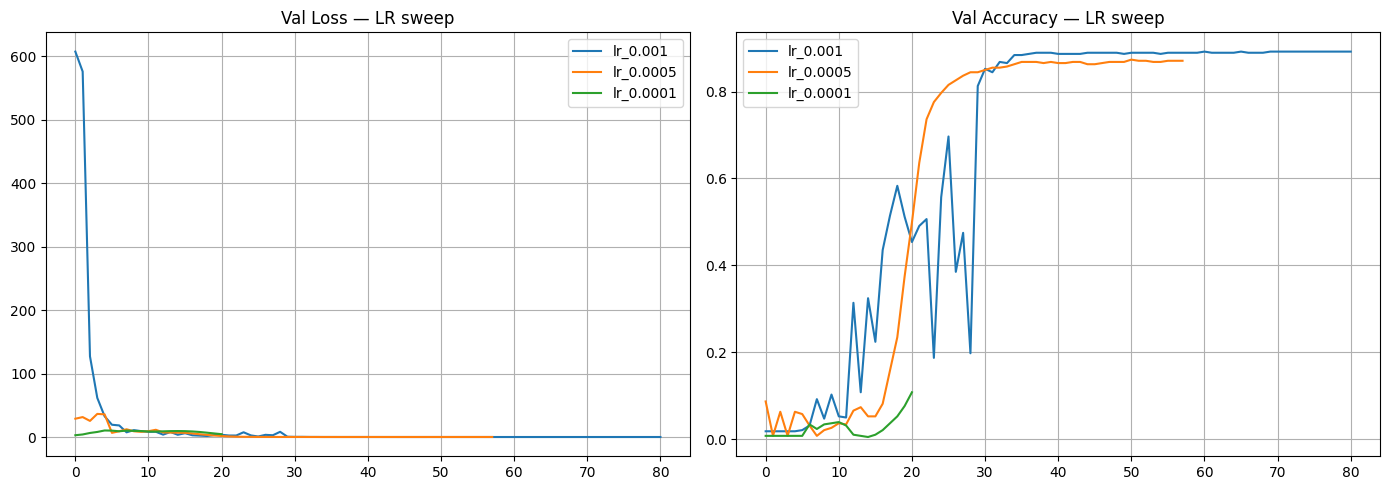

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [13]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1775573649.591707  102295 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_192556__.238


23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1003 - loss: 4.3480

I0000 00:00:1775573656.814262  102295 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_192556__.238


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 458ms/step - accuracy: 0.1445 - loss: 3.7673 - val_accuracy: 0.0950 - val_loss: 941.2217 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.3133 - loss: 2.5385 - val_accuracy: 0.0950 - val_loss: 651.8995 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.4373 - loss: 2.0819 - val_accuracy: 0.0792 - val_loss: 200.8004 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.5389 - loss: 1.6711 - val_accuracy: 0.0923 - val_loss: 69.5954 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.6148 - loss: 1.4010 - val_accuracy: 0.0792 - val_loss: 48.3571 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.6735 - loss: 1.1774 - val_accuracy: 0.0554 - val_loss: 11.7445 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.7375 - loss: 0.937

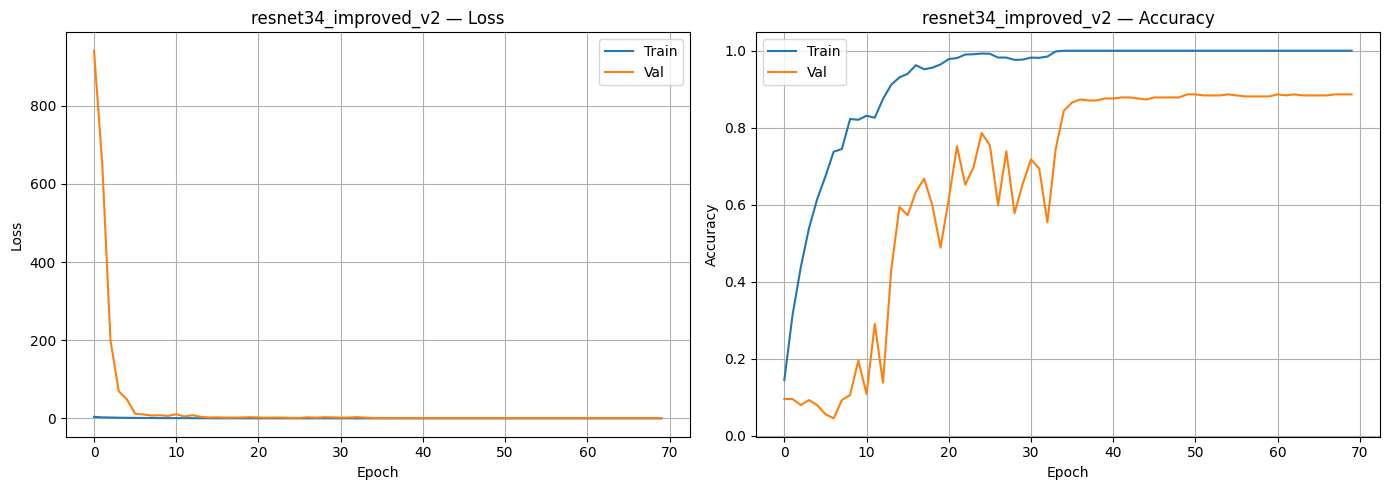

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc     = model.evaluate(X_val, y_val, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

resnet34_improved_v2 (best LR=0.001):
  Train — Loss: 0.0001, Acc: 1.0000
  Val   — Loss: 0.7121, Acc: 0.8865


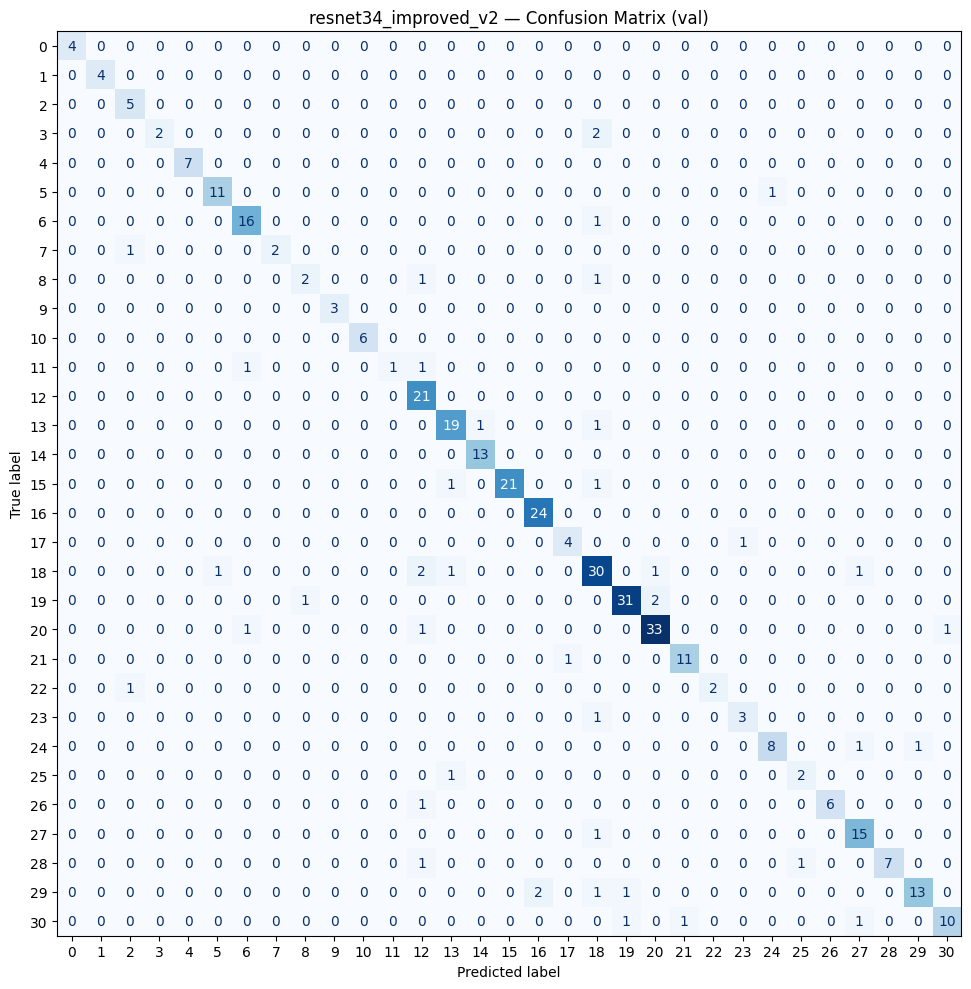

In [16]:
y_val_pred = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [17]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    X_all, y_all,
    epochs=BEST_EPOCH,
    batch_size=BATCH_SIZE,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(X_all, y_all, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 61 epochs
Epoch 1/61


I0000 00:00:1775573873.822331  102298 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1994703__.238


29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1330 - loss: 4.0916

I0000 00:00:1775573881.223888  102299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1994703__.238
I0000 00:00:1775573881.874619  123973 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 16 bytes spill stores, 16 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 366ms/step - accuracy: 0.2021 - loss: 3.4297
Epoch 2/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3910 - loss: 2.3411
Epoch 3/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5150 - loss: 1.8085
Epoch 4/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6021 - loss: 1.4138
Epoch 5/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6617 - loss: 1.2246
Epoch 6/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7113 - loss: 1.0364
Epoch 7/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7567 - loss: 0.8644
Epoch 8/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7752 - loss: 0.7836
Epoch 9/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8391 - loss: 0.5703
Epoch 10/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8807 - loss: 0.4448
Epoch 11/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9024 - loss: 0.3535
Epoch 12/61
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9045 -

I0000 00:00:1775574017.725393  127292 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 16 bytes spill stores, 16 bytes spill loads



Final train acc: 1.0000


In [18]:
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.layers[-2].output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.clip(
    np.sum(test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx], axis=1),
    0, 1
)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 357ms/step
Embedding shape: (371, 512)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v2.csv


,row_id,similarity
0,0,0.842940
1,1,0.689902
2,2,0.629350
3,3,0.710045
4,4,0.735325


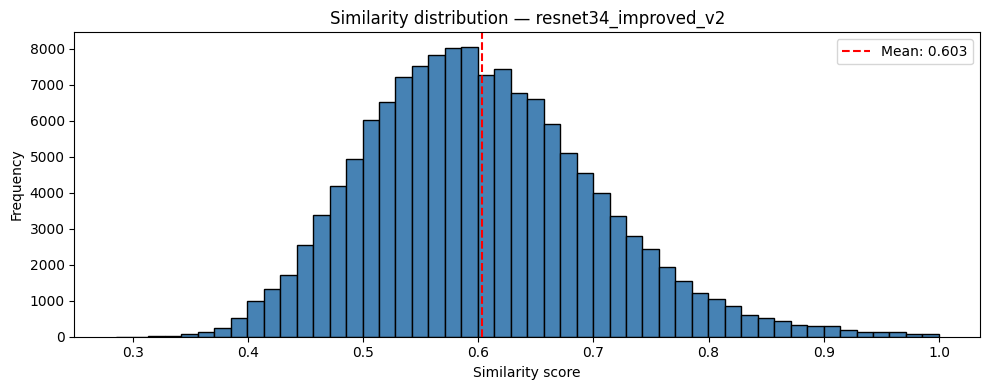

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [20]:
print(f"""
ResNet-34 improved v2:
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Best epoch: {BEST_EPOCH}
  Embedding dim: {test_embeddings.shape[1]}
  Régularisation: AdamW (wd={WEIGHT_DECAY}), Dropout(0.4)

vs ResNet-34 baseline (notebook 06):
  Train: 0.9037, Val: 0.8100
  (tanh, pas de BN, pas de regularisation, 50 epochs)

Submission -> {submission_path}
""")


ResNet-34 improved v2:
  Train - Loss: 0.0001, Acc: 1.0000
  Val   - Loss: 0.7121, Acc: 0.8865
  Best epoch: 61
  Embedding dim: 512
  Régularisation: AdamW (wd=0.0005), Dropout(0.4)

vs ResNet-34 baseline (notebook 06):
  Train: 0.9037, Val: 0.8100
  (tanh, pas de BN, pas de regularisation, 50 epochs)

Submission -> /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v2.csv



## 7. Observations & Verdict

### Results

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | TODO  | TODO |
| Loss     | TODO  | TODO |
| Overfitting ? | — | TODO |
| Kaggle Score (public) | — | TODO |
| Kaggle Score (private) | — | TODO |

### Analysis

**Architecture (vs baseline notebook 06) :**
- Remplacement de `tanh` par `BatchNorm → ReLU` : normalise les activations à chaque bloc, stabilise l'entraînement et accélère la convergence
- Shortcut projection avec `Conv1x1 → BatchNorm` : garantit la compatibilité des dimensions dans les residual connections
- `Dropout(0.4)` avant la couche de classification : régularisation pour réduire l'overfitting
- `AdamW` avec `weight_decay=5e-4` : découple la régularisation L2 de l'optimiseur, plus efficace qu'Adam classique

**Hyperparamètres du LR sweep :**
- `lr=1e-2` : souvent trop élevé pour un ResNet, risque de divergence ou d'instabilité
- `lr=1e-3` : valeur classique pour AdamW, bon compromis vitesse/stabilité
- `lr=1e-4` : convergence plus lente mais potentiellement plus stable sur des données limitées
- L'hyperparamètre le plus influent est le learning rate : un LR trop élevé empêche la convergence, un LR trop faible ralentit inutilement l'apprentissage

**Overfitting / Underfitting :**
- Le Dropout(0.4) + AdamW (weight_decay) devraient réduire l'overfitting observé dans la baseline (train=0.90 vs val=0.81)
- L'EarlyStopping (patience=10) et le ReduceLROnPlateau évitent un surapprentissage prolongé
- Si le gap train/val reste élevé → augmenter le dropout ou le weight decay

### Verdict

- [ ] Improvable -> Instructions pour v3 : tester Dropout(0.5), augmentation `heavy`, fine-tuning d'un ResNet34 pré-entraîné (transfer learning)
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff this architecture, why ?

### Interpretation

_Free Space : On note ce qu'on a à dire sur ce notebook, servira pour la soutenance._